In [1]:
# Ativa a extensão que permite rodar R dentro do ambiente Python
%load_ext rpy2.ipython

In [ ]:
%%R
# Configura o Git para usar HTTP/1.1 e evitar o erro de 'HTTP2 framing layer'
system('git config --global http.version HTTP/1.1')

# Garante a instalação das dependências
if(!require(remotes)) install.packages("remotes")

# Tenta instalar novamente o microdatasus
remotes::install_github("rfsaldanha/microdatasus", upgrade = "never")

library(microdatasus)

# Baixa os dados de internação (SIH-RD) do RS para o período solicitado
dados_brutos <- fetch_datasus(year_start=2024, year_end=2024, month_start=1, month_end=12, uf="RS", information_system="SIH-RD")

# Processa os dados
dados_limpos <- process_sih(dados_brutos)

# Salva o resultado em um arquivo CSV local
write.csv(dados_limpos, "internacoes_rs_2024.csv", row.names = FALSE)

ℹ Your local Internet connection seems to be ok.
ℹ DataSUS FTP server seems to be up and reachable.
ℹ Starting download...


Loading required package: remotes
Skipping install of 'microdatasus' from a github remote, the SHA1 (b48e7cdb) has not changed since last install.
  Use `force = TRUE` to force installation
trying URL 'ftp://ftp.datasus.gov.br/dissemin/publicos/SIHSUS/200801_/Dados/RDRS2401.dbc'
Content type 'unknown' length 5275821 bytes (5.0 MB)
trying URL 'ftp://ftp.datasus.gov.br/dissemin/publicos/SIHSUS/200801_/Dados/RDRS2402.dbc'
Content type 'unknown' length 4900440 bytes (4.7 MB)
trying URL 'ftp://ftp.datasus.gov.br/dissemin/publicos/SIHSUS/200801_/Dados/RDRS2403.dbc'
Content type 'unknown' length 5365509 bytes (5.1 MB)
trying URL 'ftp://ftp.datasus.gov.br/dissemin/publicos/SIHSUS/200801_/Dados/RDRS2404.dbc'
Content type 'unknown' length 5311672 bytes (5.1 MB)
trying URL 'ftp://ftp.datasus.gov.br/dissemin/publicos/SIHSUS/200801_/Dados/RDRS2405.dbc'
Content type 'unknown' length 5117869 bytes (4.9 MB)
trying URL 'ftp://ftp.datasus.gov.br/dissemin/publicos/SIHSUS/200801_/Dados/RDRS2406.dbc'
Conte

In [ ]:
import pandas as pd

# Agora você volta para o Python puro e lê o arquivo gerado pelo R
df_sus = pd.read_csv("internacoes_rs_2024.csv")

# Daqui para frente, segue o seu pipeline Python normalmente!
print(df_sus.head())

/tmp/ipykernel_9429/3498075103.py:4: DtypeWarning: Columns (82,84,87,88,96,97,98,99,105,106,107,108) have mixed types. Specify dtype option on import or set low_memory=False.
  df_sus = pd.read_csv("internacoes_rs_2024.csv")


    UF_ZI  ANO_CMPT  MES_CMPT ESPEC      CGC_HOSP          N_AIH      IDENT  \
0  430000      2024         1    01  4.994418e+12  4324100750464  Principal   
1  430000      2024         1    01  4.994418e+12  4324100750475  Principal   
2  430000      2024         1    01  4.994418e+12  4324100751476  Principal   
3  430000      2024         1    01  4.994418e+12  4324101518000  Principal   
4  430000      2024         1    03  4.994418e+12  4324108601505  Principal   

        CEP  MUNIC_RES        NASC  ... TPDISEC8  TPDISEC9  munResStatus  \
0  95500000     431760  1959-08-17  ...      NaN       NaN         ATIVO   
1  95500000     431760  1959-08-17  ...      NaN       NaN         ATIVO   
2  95535000     432143  1961-11-19  ...      NaN       NaN         ATIVO   
3  95590000     432160  1957-09-30  ...      NaN       NaN         ATIVO   
4  95515000     430471  1940-12-12  ...      NaN       NaN         ATIVO   

   munResTipo                 munResNome           munResUf  munResL

In [ ]:
# 1. Filtrar por Canoas
df_canoas = df_sus[df_sus['MUNIC_RES'].astype(str).str.startswith('430460')]

# 2. Filtrar por Doenças Respiratórias (Códigos que começam com 'J')
df_respiratorio = df_canoas[df_canoas['DIAG_PRINC'].str.startswith('J', na=False)].copy()

# 3. Converter a coluna de data para o padrão do Pandas
df_respiratorio['DT_INTER'] = pd.to_datetime(df_respiratorio['DT_INTER'], format='%Y-%m-%d')

# 4. Agrupar por dia para contar quantas internações ocorreram
df_saude_diario = df_respiratorio.groupby('DT_INTER').size().reset_index(name='internacoes')

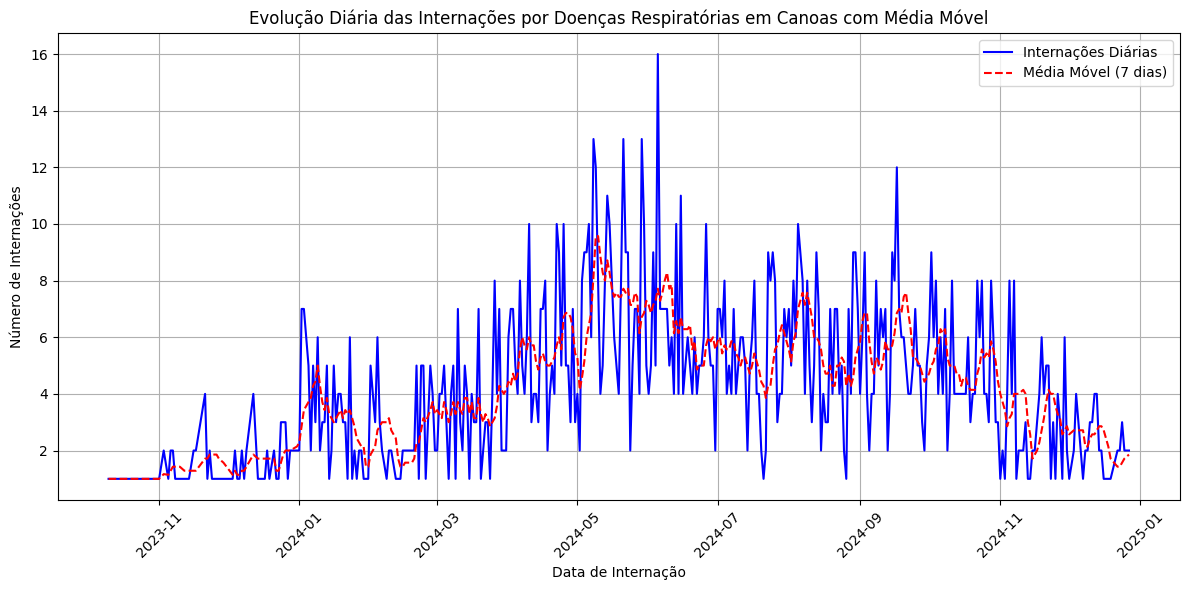

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate a 7-day moving average for smoothing
df_saude_diario['internacoes_ma'] = df_saude_diario['internacoes'].rolling(window=7, min_periods=1).mean()

plt.figure(figsize=(12, 6))
sns.lineplot(x='DT_INTER', y='internacoes', data=df_saude_diario, label='Internações Diárias', color='blue')
sns.lineplot(x='DT_INTER', y='internacoes_ma', data=df_saude_diario, label='Média Móvel (7 dias)', color='red', linestyle='--')
plt.title('Evolução Diária das Internações por Doenças Respiratórias em Canoas com Média Móvel')
plt.xlabel('Data de Internação')
plt.ylabel('Número de Internações')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_9429/3194846972.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='month_name', y='internacoes', data=monthly_avg_internacoes, palette='viridis')


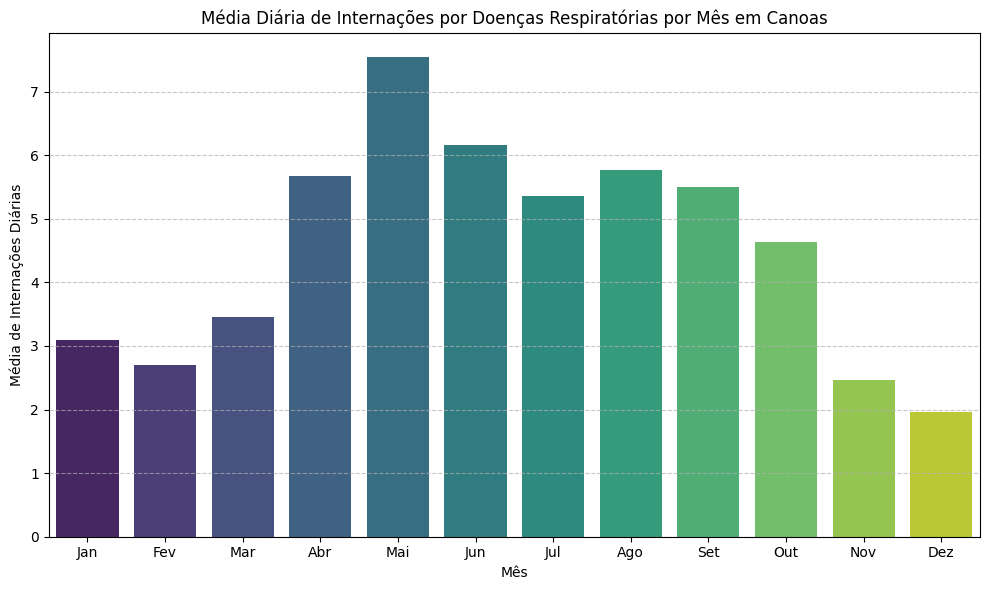

In [ ]:
# Extrair o mês da data
df_saude_diario['month'] = df_saude_diario['DT_INTER'].dt.month

# Agrupar por mês e calcular a média de internações
monthly_avg_internacoes = df_saude_diario.groupby('month')['internacoes'].mean().reset_index()

# Mapear números do mês para nomes para melhor legibilidade
month_names = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
monthly_avg_internacoes['month_name'] = monthly_avg_internacoes['month'].map(lambda x: month_names[x - 1])

plt.figure(figsize=(10, 6))
sns.barplot(x='month_name', y='internacoes', data=monthly_avg_internacoes, palette='viridis')
plt.title('Média Diária de Internações por Doenças Respiratórias por Mês em Canoas')
plt.xlabel('Mês')
plt.ylabel('Média de Internações Diárias')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Encontrar o valor máximo e a linha correspondente
max_internacoes = df_saude_diario['internacoes'].max()
dia_pico = df_saude_diario.loc[df_saude_diario['internacoes'].idxmax()]

print(f"O número máximo de internações em um único dia foi: {max_internacoes}")
print(f"Isso ocorreu no dia: {dia_pico['DT_INTER'].strftime('%d/%m/%Y')}")

O número máximo de internações em um único dia foi: 16
Isso ocorreu no dia: 05/06/2024


In [13]:
%%R
# Configura o Git para usar HTTP/1.1 e evitar o erro de 'HTTP2 framing layer'
system('git config --global http.version HTTP/1.1')

# Garante a instalação das dependências
if(!require(remotes)) install.packages("remotes")

# Tenta instalar novamente o microdatasus
remotes::install_github("rfsaldanha/microdatasus", upgrade = "never")

library(microdatasus)

# 1. Baixa os dados brutos de 2022 a 2024
dados_brutos <- fetch_datasus(year_start=2020, year_end=2020, month_start=1, month_end=12, uf="RS", information_system="SIH-RD")
dados_limpos <- process_sih(dados_brutos)

# 2. Filtrar por Canoas (MUNIC_RES == "430460")
# E filtrar por Doenças Respiratórias (DIAG_PRINC começa com "J")
# Usamos a função subset do R para fazer o equivalente ao filter do Pandas
dados_filtrados <- subset(dados_limpos,
                          grepl("^430460", MUNIC_RES) &
                          grepl("^J", DIAG_PRINC))

# 3. Salva APENAS o dataset reduzido e pronto para o uso
write.csv(dados_filtrados, "sih_respiratorio_canoas_2020.csv", row.names = FALSE)

ℹ Your local Internet connection seems to be ok.
ℹ DataSUS FTP server seems to be up and reachable.
ℹ Starting download...


Skipping install of 'microdatasus' from a github remote, the SHA1 (b48e7cdb) has not changed since last install.
  Use `force = TRUE` to force installation
trying URL 'ftp://ftp.datasus.gov.br/dissemin/publicos/SIHSUS/200801_/Dados/RDRS2001.dbc'
Content type 'unknown' length 5034917 bytes (4.8 MB)
trying URL 'ftp://ftp.datasus.gov.br/dissemin/publicos/SIHSUS/200801_/Dados/RDRS2002.dbc'
Content type 'unknown' length 4789412 bytes (4.6 MB)
trying URL 'ftp://ftp.datasus.gov.br/dissemin/publicos/SIHSUS/200801_/Dados/RDRS2003.dbc'
Content type 'unknown' length 4954868 bytes (4.7 MB)
trying URL 'ftp://ftp.datasus.gov.br/dissemin/publicos/SIHSUS/200801_/Dados/RDRS2004.dbc'
Content type 'unknown' length 3967762 bytes (3.8 MB)
trying URL 'ftp://ftp.datasus.gov.br/dissemin/publicos/SIHSUS/200801_/Dados/RDRS2005.dbc'
Content type 'unknown' length 3902506 bytes (3.7 MB)
trying URL 'ftp://ftp.datasus.gov.br/dissemin/publicos/SIHSUS/200801_/Dados/RDRS2006.dbc'
Content type 'unknown' length 3986584 b

In [18]:
import pandas as pd

df_sih_2022 = pd.read_csv("sih_respiratorio_canoas_2020.csv")

# Daqui para frente, segue o seu pipeline Python normalmente!
print(df_sih_2022.head())

    UF_ZI  ANO_CMPT  MES_CMPT  ESPEC      CGC_HOSP          N_AIH      IDENT  \
0  430460      2020         1      3  8.831413e+13  4320100022942  Principal   
1  430460      2020         1      3  8.831413e+13  4320100023019  Principal   
2  430460      2020         1      3  8.831413e+13  4320100023020  Principal   
3  430460      2020         1      3  8.831413e+13  4320100025340  Principal   
4  430460      2020         1      4  8.831413e+13  4319107935219  Principal   

        CEP  MUNIC_RES        NASC  ... TPDISEC8  TPDISEC9  munResStatus  \
0  92200150     430460  1952-08-10  ...      NaN       NaN         ATIVO   
1  92025403     430460  1942-09-21  ...      NaN       NaN         ATIVO   
2  92030490     430460  1950-01-01  ...      NaN       NaN         ATIVO   
3  92325070     430460  1953-11-09  ...      NaN       NaN         ATIVO   
4  92120140     430460  1940-12-06  ...      NaN       NaN         ATIVO   

   munResTipo  munResNome           munResUf  munResLat  munRe

In [19]:
# 4. Agrupar por dia para contar quantas internações ocorreram
# 3. Converter a coluna de data para o padrão do Pandas
df_sih_2022['DT_INTER'] = pd.to_datetime(df_sih_2022['DT_INTER'], format='%Y-%m-%d')
df_saude_diario = df_sih_2022.groupby('DT_INTER').size().reset_index(name='internacoes')

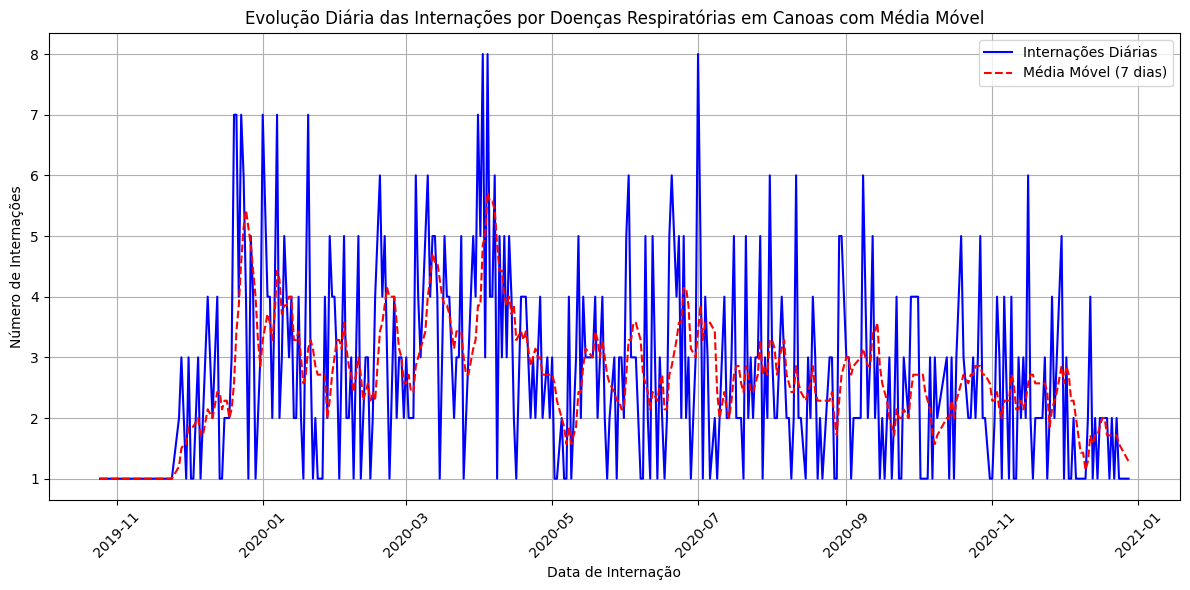

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate a 7-day moving average for smoothing
df_saude_diario['internacoes_ma'] = df_saude_diario['internacoes'].rolling(window=7, min_periods=1).mean()

plt.figure(figsize=(12, 6))
sns.lineplot(x='DT_INTER', y='internacoes', data=df_saude_diario, label='Internações Diárias', color='blue')
sns.lineplot(x='DT_INTER', y='internacoes_ma', data=df_saude_diario, label='Média Móvel (7 dias)', color='red', linestyle='--')
plt.title('Evolução Diária das Internações por Doenças Respiratórias em Canoas com Média Móvel')
plt.xlabel('Data de Internação')
plt.ylabel('Número de Internações')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_429/3194846972.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='month_name', y='internacoes', data=monthly_avg_internacoes, palette='viridis')


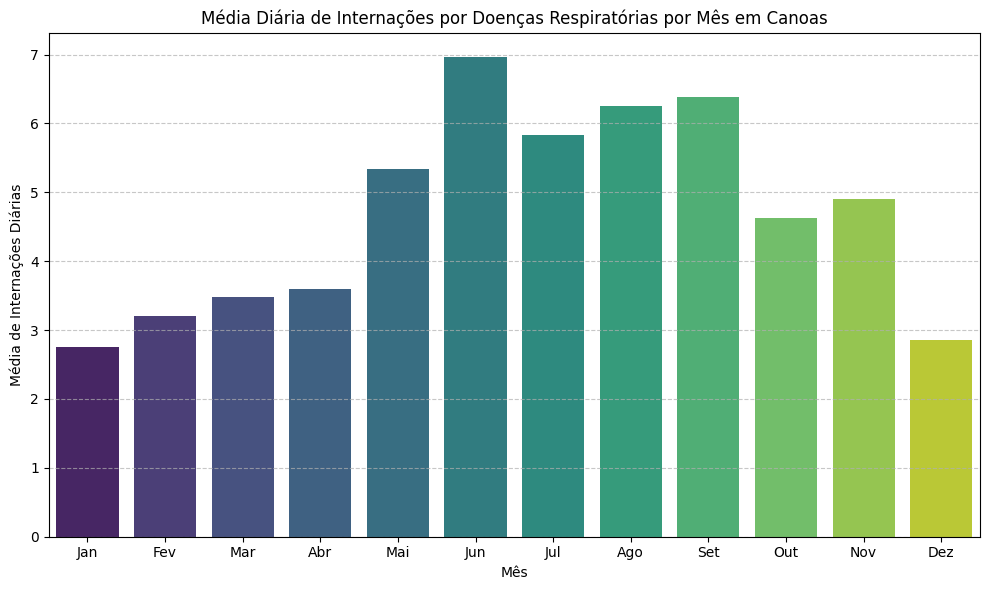

In [17]:
# Extrair o mês da data
df_saude_diario['month'] = df_saude_diario['DT_INTER'].dt.month

# Agrupar por mês e calcular a média de internações
monthly_avg_internacoes = df_saude_diario.groupby('month')['internacoes'].mean().reset_index()

# Mapear números do mês para nomes para melhor legibilidade
month_names = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
monthly_avg_internacoes['month_name'] = monthly_avg_internacoes['month'].map(lambda x: month_names[x - 1])

plt.figure(figsize=(10, 6))
sns.barplot(x='month_name', y='internacoes', data=monthly_avg_internacoes, palette='viridis')
plt.title('Média Diária de Internações por Doenças Respiratórias por Mês em Canoas')
plt.xlabel('Mês')
plt.ylabel('Média de Internações Diárias')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()